# Step 3: Connect the steps with LangGraph

Run this notebook from the top using the **.venv kernel**. You do not need to run
01 or 02 in the same session. For replay you need a JSON result saved by 02.

Previously, you called functions yourself. Now a graph controls their order and
chooses the next step based on the result. We start with a rule-based supervisor
and one AI extraction capability. More reasoning agents will come later.

**Default: replay a saved result locally. No new OpenAI call.**

## 1. Imports and environment
If LangGraph is missing, run `.\.venv\Scripts\python.exe -m pip install -r requirements-notebook.txt`
in the terminal, then restart the kernel. A **state** is the shared data passed
between nodes; a **node** is a function; an **edge** connects nodes.

In [1]:
from pathlib import Path
import json
import inspect
from dotenv import load_dotenv
from electricity_optimizer.workflow import WorkflowState, build_workflow

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "contracts").is_dir():
    raise RuntimeError("Open this notebook from the project root.")
load_dotenv(PROJECT_ROOT / ".env", override=False)
print("Project:", PROJECT_ROOT)

Project: c:\Users\Nyalo\VSCode_Projects\Electricity_Agreement_Optimizer


## 2. Select the input and mode
The PDF is re-read so citations can be checked against its actual text. Choose
a matching saved extraction JSON for replay. The fingerprint must match.

Leave `MODE = "replay"` for this lesson. Setting it to `"live"` makes one API call
when you run the graph cell; rerunning that cell makes another call.
The candidate list is sorted by filename, not freshness. Review your selection.

In [2]:
MODE = "replay"
pdf_path = PROJECT_ROOT / "contracts" / "R1F00169972621A.pdf"
candidates = sorted((PROJECT_ROOT / "output" / "extraction").glob(f"{pdf_path.stem}_*.json"))
for index, path in enumerate(candidates):
    print(index, path.name)
saved_record_path = candidates[0] if candidates else None
print("Mode:", MODE)
print("Saved record:", saved_record_path.name if saved_record_path else "None; save a result in Notebook 02 first")

0 R1F00169972621A_resp_01a98b316e99b6d6016a9f2747fc3c87d1aa09903f7c7b933b.json
Mode: replay
Saved record: R1F00169972621A_resp_01a98b316e99b6d6016a9f2747fc3c87d1aa09903f7c7b933b.json


## 3. Inspect the state
The state carries the input path, loaded document, extraction record, error,
status and trace. Each node returns just the fields it changes. LangGraph merges
those updates into the current state. Our trace is replaced with a new list
including the latest node; no parallel reducer is needed for this sequential graph.

In [3]:
print(inspect.getsource(WorkflowState))

class WorkflowState(TypedDict, total=False):
    pdf_path: str
    document: PDFDocument | None
    record: ExtractionRecord | None
    error: str | None
    status: str
    trace: list[str]



## 4. Build the graph
`StateGraph` registers nodes and edges; `compile()` creates the runnable graph.
Read `build_workflow` below to see exactly where nodes and edges are added.
A conditional edge after the supervisor selects correction or human review.

```mermaid
flowchart TD
    A[Load PDF] --> B[Extract or replay]
    A --> F[Failed]
    B --> F
    B --> C[Validate evidence]
    C --> S[Supervisor]
    S --> D[Correction required: errors]
    S --> E[Human review: warnings or no issues]
```

No path automatically declares a plan correct or ready for cost calculation.

In [4]:
graph = None
if MODE == "replay":
    if saved_record_path is not None:
        graph = build_workflow(saved_record_path=saved_record_path)
    else:
        print("No saved record. Complete the save cell in Notebook 02 first.")
elif MODE == "live":
    graph = build_workflow(live=True)
else:
    raise ValueError("MODE must be replay or live")

print(inspect.getsource(build_workflow))

def build_workflow(*, saved_record_path: Path | None = None,
                   live: bool = False,
                   extractor: Callable[[PDFDocument], ExtractionRecord] = extract_agreement):
    """Choose replay OR live explicitly. Replay never falls back to a paid call."""
    if live == (saved_record_path is not None):
        raise ValueError("Choose exactly one: saved_record_path for replay, or live=True.")

    def update(state, node, **changes):
        return {"trace": [*state.get("trace", []), node], **changes}

    def load_document(state):
        # Reset all output state for a fresh run, including after earlier failures.
        base = {"document": None, "record": None, "error": None,
                "status": "loading", "trace": ["load_document"]}
        try:
            # Keep plain text and detected cells for the same source PDF.
            base["document"] = read_pdf(Path(state["pdf_path"]), include_tables=True)
            base["status"] = "loaded"
        except (

## 5. Watch the workflow run
`stream(..., stream_mode="values")` yields the shared state after each step.
We display node names and status, rather than printing full contract text.
The saved record's issues are recomputed, so old flags cannot bypass validation.

This is the only cell that invokes the graph. In live mode it can take a minute
or two. Replay never makes an API call, including if the saved file is invalid.

The main workflow now reads detected table cells alongside original page text.
Validation checks each quote against either source, and Section 7 saves this
updated result. Restart the kernel after this update before rerunning in replay mode.

In [5]:
final_state = None
if graph is not None:
    for state in graph.stream({"pdf_path": str(pdf_path)}, stream_mode="values"):
        if state.get("trace"):
            print(f"{state['trace'][-1]} -> {state['status']}")
        final_state = state
else:
    print("Build a graph first after selecting a saved result.")

Consider using the pymupdf_layout package for a greatly improved page layout analysis.
load_document -> loaded
extract_terms -> extracted
validate_evidence -> validated
supervisor -> human_review_required
human_review -> human_review_required


## 6. Understand the supervisor's decision
- **failed**: the PDF, saved record, source match, or extraction failed.
- **correction_required**: local validation found at least one error.
- **human_review_required**: no validation errors; missing terms may still be warnings.

A correct quote does not guarantee a correct interpretation. Review nodes stop
here; they do not pause and resume with an approval. Checkpointing and actual
human-in-the-loop interrupts are a later extension.

In [6]:
if final_state is not None:
    print("Outcome:", final_state["status"])
    print("Path:", " -> ".join(final_state["trace"]))
    if final_state.get("error"):
        print("Problem:", final_state["error"])
    record = final_state.get("record")
    if record:
        for issue in record.issues:
            print(f"{issue.severity.upper()} | {issue.field}: {issue.message}")
        print("Record status:", record.review_status)

Outcome: human_review_required
Path: load_document -> extract_terms -> validate_evidence -> supervisor -> human_review
WARNING | customer_type: Not stated: obtain supporting documents before relying on this term.
WARNING | recurring_charges: Not stated: obtain supporting documents before relying on this term.
WARNING | credits_and_minimum_usage: Not stated: obtain supporting documents before relying on this term.
WARNING | renewal_terms: Not stated: obtain supporting documents before relying on this term.
Record status: needs_human_review


### Inspect the flagged quote
Run this cell after the workflow. It shows the termination-fee value, each supporting
quote, and the extracted text of its cited page. Compare these with the original PDF.
The source text is shown once per page. This cell only displays evidence; it does
not modify the result or make an API call.

In [7]:
review_state = globals().get("final_state")
if not review_state or not review_state.get("record") or not review_state.get("document"):
    print("Run the workflow cells above first. A successful extraction/replay result is needed.")
else:
    fee_term = review_state["record"].terms.termination_fee
    print("Termination fee:", fee_term.value)
    print("Status:", fee_term.status)
    source_pages = {page.page_number: page.text for page in review_state["document"].pages}
    shown_pages = set()
    if not fee_term.citations:
        print("No supporting quotes were supplied.")
    for citation in fee_term.citations:
        print(f"\n--- Quote citing page {citation.page_number} ---")
        print(citation.quote)
        if citation.page_number not in shown_pages:
            print(f"\n--- Extracted source text: page {citation.page_number} ---")
            print(source_pages.get(citation.page_number, "This page does not exist in the selected PDF."))
            shown_pages.add(citation.page_number)

Termination fee: $395 early termination fee applies through the end of the contract term; does not apply if the customer moves and provides a forwarding address and other evidence requested to verify the move.
Status: found

--- Quote citing page 1 ---
Yes. $395. Applies through the end of the contract term.

--- Extracted source text: page 1 ---
Electricity Facts Label (EFL)
                             Reliant Energy Retail Services, LLC
                              Reliant Plain and Simple 36 plan
                     AEP Texas Central service area
                                    Date: 05/10/2025
                        Average monthly use:      500 kWh         1000 kWh         2000 kWh
                      Average price per kWh:          18.2 ¢              18.2 ¢              18.2 ¢

               This price disclosure is based on the following components:
Electricity
   price                               Energy Charge:  18.2499¢  per kWh
          AEP Texas Central Delive

### Compare with the old plain-text check
This diagnostic deliberately checks only plain page text, so an interleaved table
quote may still show FAIL here. The main workflow now also checks individual table
cells. Its outcome in Section 6 and the layout lesson below reflect that broader
source evidence. This diagnostic makes no API calls and changes no records.

In [8]:
from electricity_optimizer.extraction import _normalize

check_state = globals().get("final_state")
if not check_state or not check_state.get("record") or not check_state.get("document"):
    print("Run the workflow cells above first.")
else:
    term = check_state["record"].terms.termination_fee
    print("Termination fee:", term.value)
    check_pages = {p.page_number: p.text for p in check_state["document"].pages}
    if not term.citations:
        print("No supporting citations supplied.")
    for number, citation in enumerate(term.citations, start=1):
        source = check_pages.get(citation.page_number, "")
        quote = _normalize(citation.quote)
        matches = bool(quote) and quote in _normalize(source)
        print(f"\nQuote {number}, page {citation.page_number}: {'PASS' if matches else 'FAIL'}")
        print("Quote:", quote)

    for page_number, source in check_pages.items():
        anchor = source.find("$395")
        if anchor >= 0:
            print(f"\nSource excerpt, page {page_number} (original line order):")
            print(source[max(0, anchor - 30):anchor + 620])


Termination fee: $395 early termination fee applies through the end of the contract term; does not apply if the customer moves and provides a forwarding address and other evidence requested to verify the move.

Quote 1, page 1: PASS
Quote: Yes. $395. Applies through the end of the contract term.

Quote 2, page 1: FAIL
Quote: This fee does not apply if the customer moves, and provides a forwarding address and other evidence that may be requested to verify that the customer moved.

Source excerpt, page 1 (original line order):
                         Yes. $395. Applies through the end of the contract term.
                                                         This fee does not apply if the customer moves, and provides
           Do I have a termination fee or any fees       a forwarding address and other evidence that may be
                associated with terminating service?          requested to verify that the customer moved.
            Can my price change during the contract
  

### Layout lesson: read each table cell separately
Restart the kernel after this code update, then run the notebook from the top in
replay mode. This lesson is local and makes no API call.

`include_tables=True` adds detected table cells, with row, column and bounding-box
coordinates, while preserving the original page text. If no table is found, plain
text remains available. A detection failure is reported rather than discarding text.

We match each quote against either the original text or **one individual cell**.
We never join arbitrary cells to force a match. A match still needs human review.

This lesson now demonstrates the same table-aware validation used by the main workflow.

In [9]:
from electricity_optimizer.ingestion import read_pdf
from electricity_optimizer.extraction import citation_matches, validate_terms
from IPython.display import display, HTML
from html import escape

layout_document = read_pdf(pdf_path, include_tables=True)
layout_state = globals().get("final_state")
if not layout_state or not layout_state.get("record"):
    print("Run the replay workflow above first.")
else:
    layout_record = layout_state["record"]
    if layout_record.source_sha256 != layout_document.sha256:
        raise ValueError("The selected PDF does not match the saved extraction.")
    for citation in layout_record.terms.termination_fee.citations:
        page = next((p for p in layout_document.pages if p.page_number == citation.page_number), None)
        regions = citation_matches(citation.quote, page) if page else []
        print("PASS" if regions else "FAIL", "|", regions, "|", citation.quote)
    for page in layout_document.pages:
        for cell in page.table_cells:
            if "$395" in cell.text:
                print(f"Page {page.page_number}; table {cell.table_number}; row {cell.row_number}; column {cell.column_number}")
                display(HTML("<h4>Answer read as one cell</h4><pre style='white-space:pre-wrap'>" + escape(cell.text) + "</pre>"))
    layout_issues = validate_terms(layout_record.terms, layout_document)
    print("Errors after layout-aware validation:", sum(i.severity == "error" for i in layout_issues))
    print("Warnings:", sum(i.severity == "warning" for i in layout_issues))
    print("Original workflow state and saved extraction are unchanged; human review is still required.")


PASS | ['page text', 'table 1, row 6, column 3'] | Yes. $395. Applies through the end of the contract term.
PASS | ['table 1, row 6, column 3'] | This fee does not apply if the customer moves, and provides
           a forwarding address and other evidence that may be
                requested to verify that the customer moved.
Page 1; table 1; row 6; column 3


Errors after layout-aware validation: 0
Warnings: 4
Original workflow state and saved extraction are unchanged; human review is still required.


#### Inspect the detected answer visually
The image below is rendered locally from the detected cell's coordinates in the
original PDF. Compare it with the text above. Detection is heuristic; this is not
a guarantee that every table in every agreement will be detected correctly.

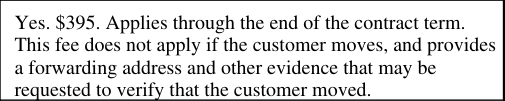

In [10]:
import pymupdf
from IPython.display import Image

with pymupdf.open(pdf_path) as pdf:
    for page in layout_document.pages:
        for cell in page.table_cells:
            if "$395" in cell.text:
                pix = pdf[page.page_number - 1].get_pixmap(clip=pymupdf.Rect(cell.bbox), matrix=pymupdf.Matrix(2, 2))
                display(Image(data=pix.tobytes("png")))


## 7. Save a workflow report
The report captures mode, source, node trace, outcome, and the revalidated result.
It is a report, not a resumable checkpoint. Re-running replaces this report;
the original Step 2 extraction remains unchanged.

In [11]:
if final_state is not None:
    record = final_state.get("record")
    report = {
        "mode": MODE,
        "pdf_path": str(pdf_path),
        "status": final_state["status"],
        "trace": final_state["trace"],
        "error": final_state.get("error"),
        "record": record.model_dump(mode="json") if record else None,
    }
    output_dir = PROJECT_ROOT / "output" / "workflow"
    output_dir.mkdir(parents=True, exist_ok=True)
    report_path = output_dir / f"{pdf_path.stem}_workflow.json"
    report_path.write_text(json.dumps(report, indent=2), encoding="utf-8")
    print("Saved:", report_path)

Saved: c:\Users\Nyalo\VSCode_Projects\Electricity_Agreement_Optimizer\output\workflow\R1F00169972621A_workflow.json


## Learning exercise
1. Find the `supervisor` function in the displayed source. Which line distinguishes
   an error from a warning?
2. Follow `add_conditional_edges` to find the branch that handles extraction failure.
3. In replay mode, select a different PDF without changing the JSON selection,
   rebuild the graph and rerun. The source mismatch should end in `failed`.
   Restore the original selection afterward.

**Next:** validate 12 months of usage and build explicit pricing rules for compatible
plans. Comparison and explanation agents will be connected as those capabilities
are added. This workflow is not yet the complete multi-agent optimizer.

[LangGraph Graph API documentation](https://docs.langchain.com/oss/python/langgraph/graph-api)
explains state, nodes, and conditional edges. Restart the kernel after editing
imported modules, and clear outputs before sharing private document data.